In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [3]:
import pydot
import graphviz
print("Successfully imported!")


Successfully imported!


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("../data/selected_features.csv")

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['target'])

# Train-Test Split
X = df.drop(columns=['target']).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
import json
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Step 1: Compute class weights
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Step 2: Define the FNN model
fnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Step 3: Compile the model
fnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Step 4: Train the model with class weights
history_fnn = fnn_model.fit(X_train, y_train,
                            validation_data=(X_test, y_test),
                            epochs=50,
                            batch_size=32,
                            class_weight=class_weight_dict)

# Step 5: Save the model and training history
fnn_model.save("../models/fnn_model.h5")
with open("../models/fnn_history.json", "w") as f:
    json.dump(history_fnn.history, f)


C:\Users\dedee\Downloads\Epitope_Prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5030 - loss: 68.4929 - val_accuracy: 0.5007 - val_loss: 1.0362
Epoch 2/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5050 - loss: 2.0125 - val_accuracy: 0.5048 - val_loss: 0.6957
Epoch 3/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5099 - loss: 0.9727 - val_accuracy: 0.4988 - val_loss: 0.7030
Epoch 4/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5036 - loss: 0.8149 - val_accuracy: 0.5009 - val_loss: 0.7071
Epoch 5/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5006 - loss: 0.7961 - val_accuracy: 0.5009 - val_loss: 0.7028
Epoch 6/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5023 - loss: 0.7584 - val_accuracy: 0.5127 - val_loss: 0.6923
Epoch 7/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5062 - loss: 0.7548 - val_accuracy: 0.4940 - val_loss: 0.6945
Epoch 8/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5057 - loss: 0.7129 - val_accuracy: 0

In [6]:
import json
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Reshape input for LSTM
X_train_LSTM = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_LSTM = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[1])),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_lstm = lstm_model.fit(X_train_LSTM, y_train, validation_data=(X_test_LSTM, y_test), epochs=50, batch_size=32)

# Save the model (you can use .keras instead of .h5 if you prefer)
lstm_model.save("../models/lstm_model.h5")

# Save training history
with open("../models/lstm_history.json", "w") as f:
    json.dump(history_lstm.history, f)


C:\Users\dedee\Downloads\Epitope_Prediction\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5322 - loss: 0.6910 - val_accuracy: 0.5451 - val_loss: 0.6889
Epoch 2/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5413 - loss: 0.6890 - val_accuracy: 0.5419 - val_loss: 0.6891
Epoch 3/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5401 - loss: 0.6880 - val_accuracy: 0.5380 - val_loss: 0.6896
Epoch 4/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5383 - loss: 0.6892 - val_accuracy: 0.5405 - val_loss: 0.6910
Epoch 5/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5369 - loss: 0.6889 - val_accuracy: 0.5532 - val_loss: 0.6882
Epoch 6/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5423 - loss: 0.6883 - val_accuracy: 0.5504 - val_loss: 0.6886
Epoch 7/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5423 - loss: 0.6891 - val_accuracy: 0.5435 - val_loss: 0.6883
Epoch 8/50
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5396 - loss: 0.6889 - val_accuracy: 0

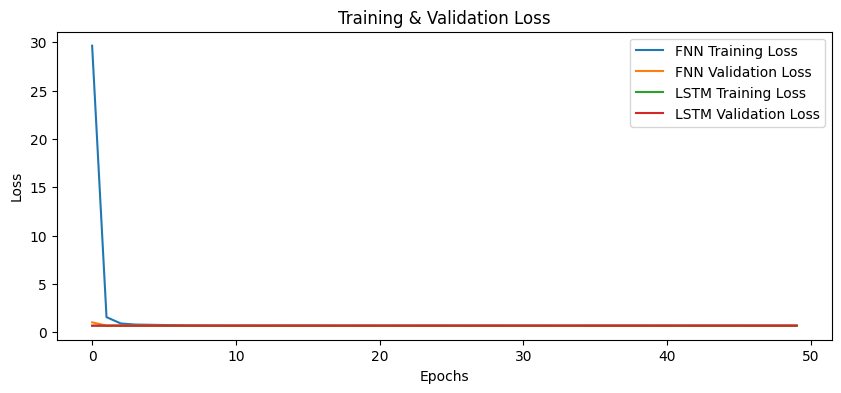

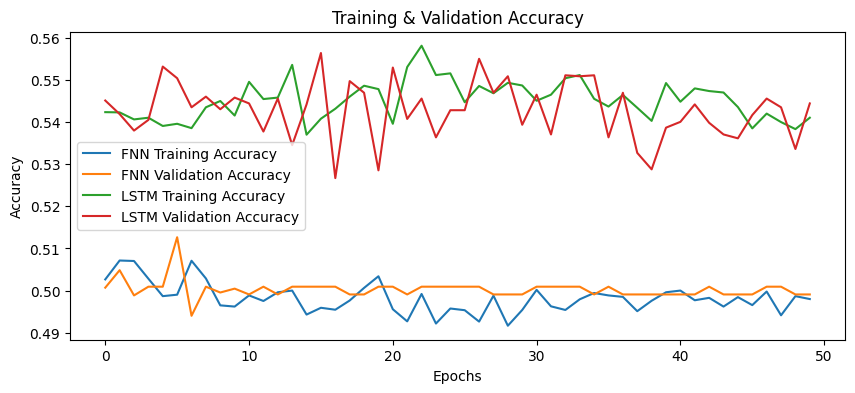

In [7]:
import json
import matplotlib.pyplot as plt

# Load saved training histories
with open("../models/fnn_history.json", "r") as f:
    fnn_history = json.load(f)

with open("../models/lstm_history.json", "r") as f:
    lstm_history = json.load(f)

# Plot Loss
plt.figure(figsize=(10, 4))
plt.plot(fnn_history["loss"], label="FNN Training Loss")
plt.plot(fnn_history["val_loss"], label="FNN Validation Loss")
plt.plot(lstm_history["loss"], label="LSTM Training Loss")
plt.plot(lstm_history["val_loss"], label="LSTM Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.plot(fnn_history["accuracy"], label="FNN Training Accuracy")
plt.plot(fnn_history["val_accuracy"], label="FNN Validation Accuracy")
plt.plot(lstm_history["accuracy"], label="LSTM Training Accuracy")
plt.plot(lstm_history["val_accuracy"], label="LSTM Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


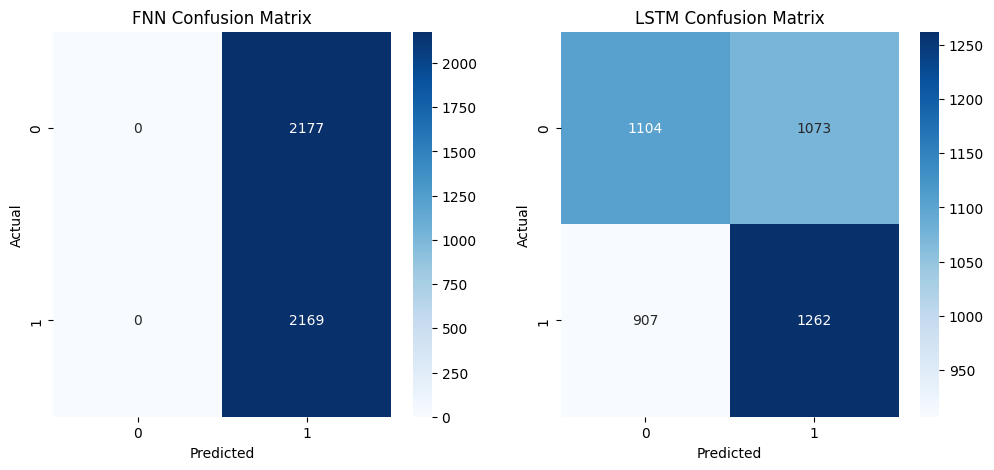

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
fnn_preds = (fnn_model.predict(X_test) > 0.5).astype(int).flatten()
lstm_preds = (lstm_model.predict(X_test_LSTM) > 0.5).astype(int).flatten()

# Confusion matrices
fnn_cm = confusion_matrix(y_test, fnn_preds)
lstm_cm = confusion_matrix(y_test, lstm_preds)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(fnn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("FNN Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("LSTM Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.show()
